# Simple Graph

### define the state object

In [ ]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str

### define nodes

In [ ]:
def node_1(state):
    print("---NODE 1---")
    return {"graph_state": state['graph_state'] + " I am"}

def node_2(state):
    print("---NODE 2---")
    return {"graph_state": state['graph_state'] + " happy"}

def node_3(state):
    print("---NODE 3---")
    return {"graph_state": state['graph_state'] + " sad"}

### Creating edges and a conditional edge

In [ ]:
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:
    user_input = state['graph_state']

    if random.random() < 0.5:
        return "node_2"

    return "node_3"

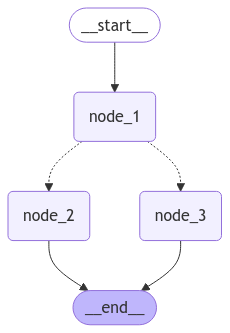

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

#build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

#Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

#add
graph = builder.compile()

# view
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({"graph_state": "hey im ritik"})

---NODE 1---
---NODE 2---


{'graph_state': 'hey im ritik I am happy'}

# CHAIN

In [ ]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


In [ ]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

KeyboardInterrupt: Interrupted by user

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")
result = llm.invoke(messages)
type(result)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

### currently openai have exeeded the usage limits so we changed it to gemini

In [ ]:
%pip install -qU langchain-google-genai

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from dotenv import load_dotenv
import os
load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

In [ ]:
import os

# Replace with the actual path to your service account key
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "agent-12b15-e2526307cc70.json"

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-1.5-pro",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

result = llm.invoke(messages)
print(type(result))


<class 'langchain_core.messages.ai.AIMessage'>


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-1.5-pro")


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-exp")
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [ ]:
result

AIMessage(content='Okay, if you want to see Orcas in the US, the **San Juan Islands in Washington State** are generally considered the **best place**. Here\'s why:\n\n*   **Resident Orca Populations:** The Salish Sea, which surrounds the San Juan Islands, is home to several pods of Resident Orcas (also known as the Southern Resident Killer Whales). These orcas eat fish, primarily salmon, and are typically seen in the area from late spring through early fall.\n*   **Accessibility and Whale Watching Tours:** Numerous reputable whale watching tour operators are based in towns like Friday Harbor on San Juan Island. These tours are designed to maximize your chances of seeing orcas while also being mindful of their well-being.\n*   **Land-Based Viewing Opportunities:** You don\'t necessarily have to take a boat tour. There are several parks and shorelines on the San Juan Islands that offer good opportunities to spot orcas from land, especially Lime Kiln Point State Park (nicknamed "Whale Wat

In [ ]:
result.response_metadata

{'prompt_feedback': {'block_reason': 0, 'safety_ratings': []},
 'finish_reason': 'STOP',
 'safety_ratings': []}

# Tool Calling

In [ ]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

In [ ]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])
tool_call

AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2.0, "b": 3.0}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-ce86aec8-05c2-493f-832c-98b2a22708f4-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2.0, 'b': 3.0}, 'id': '5114138e-8dbe-409c-a52b-ce64b1ce9cb8', 'type': 'tool_call'}], usage_metadata={'input_tokens': 22, 'output_tokens': 3, 'total_tokens': 25, 'input_token_details': {'cache_read': 0}})

In [ ]:
tool_call.additional_kwargs

{'function_call': {'name': 'multiply', 'arguments': '{"a": 2.0, "b": 3.0}'}}

# Reducers
### without them the state got updated instead of append

In [ ]:
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [ ]:
from langgraph.graph import MessagesState

class State(MessagesState):
    pass


### Test

In [ ]:
initial_message = [AIMessage(content="HELLOW! How can i gel i am AI", name="model"),
                    HumanMessage(content="Im looking for a solution i am human", name="Ritik")]

#new message
new_message = AIMessage(content="Sure as i am ai i can help", name="model")

#test
add_messages(initial_message, new_message)

[AIMessage(content='HELLOW! How can i gel i am AI', additional_kwargs={}, response_metadata={}, name='model', id='fcbbe56f-f22e-4459-8e2b-170f3fa19c87'),
 HumanMessage(content='Im looking for a solution i am human', additional_kwargs={}, response_metadata={}, name='Ritik', id='51934c60-b2aa-48df-a6e4-bf9d06d1e494'),
 AIMessage(content='Sure as i am ai i can help', additional_kwargs={}, response_metadata={}, name='model', id='609a69d3-e22c-44f3-83ff-19504b51f484')]

### Lets see that with graph

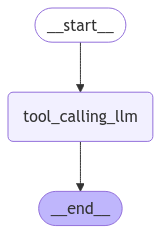

In [ ]:
from langgraph.graph import StateGraph, START, END

#State
class MessagesState(MessagesState):
    pass

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

#building graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
messages = graph.invoke({"messages": HumanMessage(content="Hellow")})
messages

{'messages': [HumanMessage(content='Hellow', additional_kwargs={}, response_metadata={}, id='e81379fd-27b5-4ba2-973b-33115319dedd'),
  AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-2a58ec4e-990b-4405-93fe-733ae2491a0a-0', usage_metadata={'input_tokens': 16, 'output_tokens': 10, 'total_tokens': 26, 'input_token_details': {'cache_read': 0}})]}

### tool call

In [ ]:
messages = graph.invoke({"messages": HumanMessage("Multiply 2 and 3")})
messages

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='770d7b3a-ff6c-4caa-82f2-e36cc332f626'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2.0, "b": 3.0}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-d78ac59b-adeb-4f0f-af0c-080e02fc9628-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2.0, 'b': 3.0}, 'id': 'ad9f80e2-910b-4bc4-9b4d-2cf09c8a00ef', 'type': 'tool_call'}], usage_metadata={'input_tokens': 20, 'output_tokens': 3, 'total_tokens': 23, 'input_token_details': {'cache_read': 0}})]}

# Router

In [ ]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-exp")
llm_with_tools = llm.bind_tools([multiply])

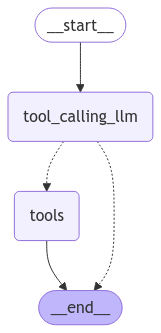

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message (result) from assistant is a not a tool call -> tools_condition routes to End
    tools_condition,
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage

messages = [HumanMessage(content="multiply 2 and 4 then multiply the output by 5")]
messages = graph.invoke({"messages": messages})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

multiply 2 and 4 then multiply the output by 5
================================== Ai Message ==================================
Tool Calls:
  multiply (470f1802-848c-4964-aacd-56564a1a80bf)
 Call ID: 470f1802-848c-4964-aacd-56564a1a80bf
  Args:
    a: 2.0
    b: 4.0
================================= Tool Message =================================
Name: multiply

8


# Setup langsmith

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "agent-12b15-e2526307cc70.json"


os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
lln = ChatGoogleGenerativeAI(model="gemini-2.0-flash-exp", temperature=0)

llm.invoke("hello world")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-cc8378ee-a437-4ea5-b410-6ab45b9076c7-0', usage_metadata={'input_tokens': 3, 'output_tokens': 10, 'total_tokens': 13, 'input_token_details': {'cache_read': 0}})

In [ ]:
# Cell 1: Install Required Packages (Run only once)
# Uncomment and run if you haven't installed the required packages in your Jupyter environment
# !pip install langchain_core langgraph langchain_google_genai langsmith python-dotenv

# Cell 2: Import Libraries and Set Environment Variables
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Set environment variables
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "agent-12b15-e2526307cc70.json"
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")

# Verify environment variables are set correctly
print("GOOGLE_APPLICATION_CREDENTIALS:", os.getenv("GOOGLE_APPLICATION_CREDENTIALS"))
print("OPENAI_API_KEY:", os.getenv("OPENAI_API_KEY") is not None)
print("LANGCHAIN_API_KEY:", os.getenv("LANGCHAIN_API_KEY") is not None)

# Cell 3: Import LangChain and LangGraph Components
from langchain_core.messages import HumanMessage, SystemMessage, RemoveMessage
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

# Cell 4: Initialize the Model
# Initialize the Gemini model
model = ChatGoogleGenerativeAI(model="gemini-2.0-flash-exp", temperature=0)

# Cell 5: Define the State Class
# Define the State class to store messages and summary
class State(MessagesState):
    summary: str = ""  # Initialize summary to an empty string

# Cell 6: Define Workflow Functions

def call_model(state: State):
    """
    Calls the Gemini model with the current messages.
    If a summary exists, it adds it as a system message.
    """
    summary = state.get("summary", "")

    if summary:
        system_message = f"Summary of conversation earlier: {summary}"
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]

    response = model.invoke(messages)
    return {"messages": response}

def should_continue(state: State):
    """
    Determines the next node based on the number of messages.
    If more than six messages, proceed to summarize.
    Otherwise, end the conversation.
    """
    messages = state["messages"]

    if len(messages) > 6:
        return "summarize_conversation"

    return END

def summarize_conversation(state: State):
    """
    Summarizes the conversation and updates the state.
    """
    summary = state.get("summary", "")

    if summary:
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
    else:
        summary_message = "Create a summary of the conversation above:"

    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)

    # Attempt to remove older messages
    try:
        delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    except AttributeError as e:
        print("Error removing messages:", e)
        delete_messages = []  # Fallback: Do not remove messages if 'id' is missing

    return {"summary": response.content, "messages": delete_messages}

# Cell 7: Define and Compile the Graph

# Initialize the workflow graph
workflow = StateGraph(State)

# Add nodes
workflow.add_node("conversation", call_model)
workflow.add_node("summarize_conversation", summarize_conversation)

# Set edges
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile the graph
graph = workflow.compile()

# Cell 8: Invoke the Graph

# Prepare the initial input with a list of message objects
initial_input = {
    "messages": [HumanMessage(content="hey")]
}

# Invoke the graph and capture the final state
try:
    final_state = graph.invoke(initial_input)
    print("Final state:", final_state)
except Exception as e:
    print("Error during graph invocation:", e)


GOOGLE_APPLICATION_CREDENTIALS: agent-12b15-e2526307cc70.json
OPENAI_API_KEY: True
LANGCHAIN_API_KEY: True
Final state: {'messages': [HumanMessage(content='hey', additional_kwargs={}, response_metadata={}, id='a1146133-42ee-4a01-820a-71f55fdf604e'), AIMessage(content='Hey there! How can I help you today?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': [{'category': 'HARM_CATEGORY_HATE_SPEECH', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_DANGEROUS_CONTENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_HARASSMENT', 'probability': 'NEGLIGIBLE', 'blocked': False}, {'category': 'HARM_CATEGORY_SEXUALLY_EXPLICIT', 'probability': 'NEGLIGIBLE', 'blocked': False}]}, id='run-1336872e-ce34-4dd8-85db-c4803755163f-0', usage_metadata={'input_tokens': 2, 'output_tokens': 11, 'total_tokens': 13, 'input_token_details': {'cache_read': 0}})]}


# Agent

In [ ]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-exp")
llm_with_tools = llm.bind_tools(tools)

In [ ]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

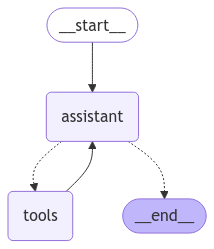

In [ ]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
messages = [HumanMessage(content="Add 3 and 4. Multiply the output by 2. Divide the output by 5")]
messages = react_graph.invoke({"messages": messages})

In [ ]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4. Multiply the output by 2. Divide the output by 5
================================== Ai Message ==================================
Tool Calls:
  add (5d4cf287-9999-474d-a0c0-568465033bad)
 Call ID: 5d4cf287-9999-474d-a0c0-568465033bad
  Args:
    a: 3.0
    b: 4.0
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Tool Calls:
  multiply (70059600-23ec-4687-b80d-719e58a01004)
 Call ID: 70059600-23ec-4687-b80d-719e58a01004
  Args:
    a: 7.0
    b: 2.0
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================
Tool Calls:
  divide (9af20016-52b6-4f75-a6fb-403bfd28a027)
 Call ID: 9af20016-52b6-4f75-a6fb-403bfd28a027
  Args:
    a: 14.0
    b: 5.0
========

# Agent with Memory

In [ ]:
_set_env("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "pr-internal-diploma-50"

LANGCHAIN_API_KEY:  ········


In [ ]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-exp")
llm_with_tools = llm.bind_tools(tools)

In [ ]:
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

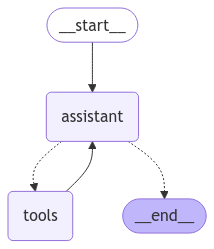

In [ ]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
messages = [HumanMessage(content="Add 3 and 4.")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (30566074-de16-4bd5-86e7-940297d65030)
 Call ID: 30566074-de16-4bd5-86e7-940297d65030
  Args:
    a: 3.0
    b: 4.0
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

7


In [ ]:
messages = [HumanMessage(content="Multiply that by 2.")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================

I'm sorry, I need more information to perform this request. Could you please tell me what number you'd like to multiply by 2?


In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

In [ ]:
# Specify a thread
config = {"configurable": {"thread_id": "1"}}

# Specify an input
messages = [HumanMessage(content="Add 3 and 4.")]

# Run
messages = react_graph_memory.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (03a60162-2755-4750-9a52-ea78222695f0)
 Call ID: 03a60162-2755-4750-9a52-ea78222695f0
  Args:
    a: 3.0
    b: 4.0
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

7


In [ ]:
messages = [HumanMessage(content="Multiply that by 2.")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (03a60162-2755-4750-9a52-ea78222695f0)
 Call ID: 03a60162-2755-4750-9a52-ea78222695f0
  Args:
    a: 3.0
    b: 4.0
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

7
================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (54b9e434-a0bd-4fee-bc15-798506ec2090)
 Call ID: 54b9e434-a0bd-4fee-bc15-798506ec2090
  Args:
    a: 7.0
    b: 2.0
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================

14


In [ ]:
messages = [HumanMessage(content="add 5 to that")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (03a60162-2755-4750-9a52-ea78222695f0)
 Call ID: 03a60162-2755-4750-9a52-ea78222695f0
  Args:
    a: 3.0
    b: 4.0
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

7
================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (54b9e434-a0bd-4fee-bc15-798506ec2090)
 Call ID: 54b9e434-a0bd-4fee-bc15-798506ec2090
  Args:
    a: 7.0
    b: 2.0
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================

14
=====

# Using different State

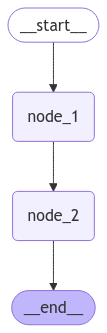

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class OverallState(TypedDict):
    foo: int

class PrivateState(TypedDict):
    baz: int

def node_1(state: OverallState) -> PrivateState:
    print("--NODE_1--")
    return {"baz" : state['foo'] +1}

def node_2(state: PrivateState) -> OverallState:
    print("--NODE_2--")
    return {"foo": state["baz"] + 1}

#add node
builder = StateGraph(OverallState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# add
graph = builder.compile()

#view
graph

In [ ]:
graph.invoke({"foo" : 2})

--NODE_1--
--NODE_2--


{'foo': 4}

# specific input and output state

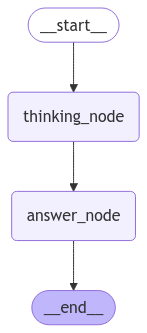

In [ ]:
class InputState(TypedDict):
    question: str

class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: InputState):
    return {"answer": "bye",  "notes": "this is a note"}

def answer_node(state: OverallState) -> OutputState:
    return {"answer": "bye this is answer"}

builder = StateGraph(OverallState, input=InputState, output=OutputState)
builder.add_node("thinking_node", thinking_node)
builder.add_node("answer_node", answer_node)

builder.add_edge(START, "thinking_node")
builder.add_edge("thinking_node", "answer_node")
builder.add_edge("answer_node", END)

graph = builder.compile()
graph

In [ ]:
graph.invoke({"question": "hey"})

{'answer': 'bye this is answer'}

# Trim and filter messages

In [ ]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(f"So u sai u were researching ocean mamals", name="Bot")]
messages.append(HumanMessage(f"yes i know about whales but what other should i learn about", name="ritik"))

for m in messages:
    m.pretty_print()


================================== Ai Message ==================================
Name: Bot

So u sai u were researching ocean mamals
================================ Human Message =================================
Name: ritik

yes i know about whales but what other should i learn about


In [ ]:
# as u know we can pass list of messages

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-exp")

llm.invoke(messages)

AIMessage(content="Okay, great! Since you're already familiar with whales, there's a whole fascinating world of other ocean mammals to explore! Here are some suggestions, broken down by categories, to help you decide what you might want to learn about next:\n\n**1. Pinnipeds (Seals, Sea Lions, and Walruses):**\n\n*   **Seals:**\n    *   **Harbor Seal:** Common, found in coastal waters. Known for their spotted coats and generally solitary nature.\n    *   **Elephant Seal:** Enormous, with males having large, trunk-like noses. Known for their impressive breeding colonies.\n    *   **Leopard Seal:** Apex predators in Antarctica, known for their aggressive hunting of penguins and other seals.\n    *   **Crab-eater Seal:** Abundant in Antarctica, despite their name, they primarily eat krill.\n\n*   **Sea Lions:**\n    *   **California Sea Lion:** Playful and intelligent, often seen in zoos and aquariums. Known for their barking and agility.\n    *   **Steller Sea Lion:** The largest sea lio

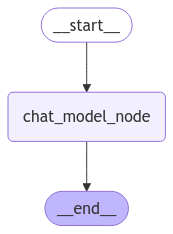

In [ ]:
#and we can run the model in  simple state graph

from langgraph.graph import MessageGraph, StateGraph, START, END

def chat_model_node(state: MessageState):
    return {"messages": llm.invoke(state["messages"])}

#build graph
builder = StateGraph(MessageState)
builder.add_node("chat_model_node", chat_model_node)

builder.add_edge(START, "chat_model_node")
builder.add_edge("chat_model_node", END)

graph = builder.compile()

graph

In [ ]:
output = graph.invoke({"messages": messages})

for m in output['messages']:
    m.pretty_print()


================================== Ai Message ==================================
Name: Bot

So u sai u were researching ocean mamals
================================ Human Message =================================
Name: ritik

yes i know about whales but what other should i learn about
================================== Ai Message ==================================

Okay, that's great you're interested in ocean mammals beyond whales! There's a huge diversity out there, and each group has fascinating characteristics. Here are some other groups of ocean mammals you could explore, along with some interesting facts about each:

**1. Dolphins & Porpoises (Cetaceans - Odontocetes):**

*   **Why they're interesting:** Often confused with each other, dolphins and porpoises are highly intelligent, social, and use echolocation to navigate and hunt. They also have complex communication systems.
*   **Things to explore:**
    *   **Differences between dolphins and porpoises:** (e.g., body shape, b

### to reduce cost we use reducer to remove most of the messages and keep the initial and  last 2 messages only with help of reducers

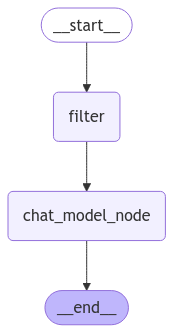

In [ ]:
from langchain_core.messages import RemoveMessage

#NODES
def filter_messages(state: MessageState):
    # Delete all but the 2 most recent
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessageState):
    return {"messages": [llm.invoke(state["messages"])]}


builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model_node", chat_model_node)

builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model_node")
builder.add_edge("chat_model_node", END)

graph = builder.compile()

graph

In [ ]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's great! Whales are fascinating. Since you're branching out from whales, there's a whole world of amazing ocean mammals to explore. To give you some good starting points, let's break them down into a few categories and I'll give you some examples of each:

**1. Pinnipeds (The "Fin-Footed" Ones):** These are the semi-aquatic mammals that have flippers and spend time both in the water and on land/ice.

*   **Seals:**
    *   **Harbor Seal:** Common and widely distributed, they are known for their spotted coats.
    *   **Elephant Seal:** Massive, with males having a large, trunk-like nose. They are incredible 

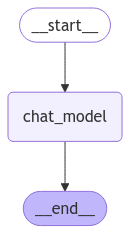

In [ ]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Lance"))

In [ ]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's great! Whales are fascinating. Since you're branching out from whales, there's a whole world of amazing ocean mammals to explore. To give you some good starting points, let's break them down into a few categories and I'll give you some examples of each:

**1. Pinnipeds (The "Fin-Footed" Ones):** These are the semi-aquatic mammals that have flippers and spend time both in the water and on land/ice.

*   **Seals:**
  

In [ ]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

That's great! Whales are fascinating. Since you're branching out from whales, there's a whole world of amazing ocean mammals to explore. To give you some good starting points, let's break them down into a few categories and I'll give you some examples of each:

**1. Pinnipeds (The "Fin-Footed" Ones):** These are the semi-aquatic mammals that have flippers and spend time both in the water and on land/ice.

*   **Seals:**
  

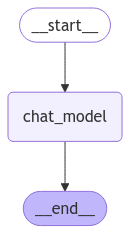

In [ ]:
from langchain_core.messages import trim_messages

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=ChatGoogleGenerativeAI(model="gemini-2.0-flash-exp"),
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))

In [ ]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=ChatGoogleGenerativeAI(model="gemini-2.0-flash-exp"),
            allow_partial=False
        )

[HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Lance')]

# Summary

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(model="gemini-1.5-pro", temperature=0)

In [ ]:
from langgraph.graph import MessagesState
class State(MessagesState):
    summary: str

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

def call_model(state:State):
    #get  summary if exist
    summary = state.get("summary", "")

    # if there is summary then we add it
    if summary:
        #add summary to system message
        system_message = f"summary of the concersation earlier: {summary}"

        #append the summary to any new message
        messages = [SystemMessage(content=system_message)] + state["messages"]

    else:
        messages = state["messages"]

    response = model.invoke(messages)
    return {"messages": response}

In [ ]:
def summarize_conversation(state: State):

    #first we add existing summary
    summary = state.get("summary", "")

    # create our summarization prompt
    if summary:

        # summary already exist
        summary_message = (
            f"this is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )

    else:
        summary_message = "create a summary of the conversation above:"

    #add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)

    #delete all but 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

In [ ]:
# when to do the summary

from langgraph.graph import END

def should_continue(state: State):
    """Return the next node to execute"""

    messages = state["messages"]

    # if there ar more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"

    #otherwise we can just end
    return END

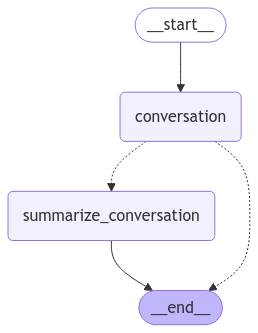

In [ ]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

### thread and memory

In [ ]:
#creating a congig
config = {"configurable": {"thread_id": "1"}}

#start convo
input_message = HumanMessage(content="Hi  iam ritik")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

#start convo
input_message = HumanMessage(content="whats my name")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()


#start convo
input_message = HumanMessage(content="i like the 49ers")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Hi Ritik! How can I help you today?
================================== Ai Message ==================================

You said your name is Ritik.
================================== Ai Message ==================================

That's cool!  They have a rich history and a passionate fan base.  Are you excited for the upcoming season?


#### we didnt have summary coz we still didnt have message > 6

In [ ]:
graph.get_state(config).values.get("summary", "")

''

In [ ]:
input_message = HumanMessage(content="i like the nick")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

You like the Niners' quarterback, Nick Bosa? He's a dominant player and a key part of their defense.  Or are you referring to a different Nick?


In [ ]:
graph.get_state(config).values.get("summary", "")

"We had a brief introduction where I learned your name is Ritik. You mentioned you're a 49ers fan and expressed your liking for Nick Bosa, presumably the defensive end."

# SQL lite

In [ ]:
import sqlite3
# In memory
conn = sqlite3.connect(":memory:", check_same_thread = False)

In [ ]:
# pull file if it doesn't exist and connect to local db
!mkdir -p state_db && [ ! -f state_db/example.db ] && wget -P state_db https://github.com/langchain-ai/langchain-academy/raw/main/module-2/state_db/example.db

db_path = "state_db/example.db"
conn = sqlite3.connect(db_path, check_same_thread=False)

--2025-01-18 16:36:04--  https://github.com/langchain-ai/langchain-academy/raw/main/module-2/state_db/example.db
20.207.73.82thub.com (github.com)... 
Connecting to github.com (github.com)|20.207.73.82|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/langchain-ai/langchain-academy/main/module-2/state_db/example.db [following]
--2025-01-18 16:36:04--  https://raw.githubusercontent.com/langchain-ai/langchain-academy/main/module-2/state_db/example.db
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8000::154, 2606:50c0:8001::154, 2606:50c0:8002::154, ...
connected. to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8000::154|:443... 
HTTP request sent, awaiting response... 200 OK
Length: 110592 (108K) [application/octet-stream]
Saving to: ‘state_db/example.db’

example.db          100%[===================>] 108.00K  --.-KB/s    in 0.08s   

2025-01-18 16:36:05 (1.27 MB/s) - ‘state_d

In [ ]:
# Here is our checkpointer
from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver(conn)

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

from langgraph.graph import END
from langgraph.graph import MessagesState

from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(model="gemini-1.5-pro", temperature=0)

class State(MessagesState):
    summary: str

# Define the logic to call the model
def call_model(state: State):

    # Get summary if it exists
    summary = state.get("summary", "")

    # If there is summary, then we add it
    if summary:

        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]

    else:
        messages = state["messages"]

    response = model.invoke(messages)
    return {"messages": response}

def summarize_conversation(state: State):

    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt
    if summary:

        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )

    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)

    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# Determine whether to end or summarize the conversation
def should_continue(state: State):

    """Return the next node to execute."""

    messages = state["messages"]

    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"

    # Otherwise we can just end
    return END

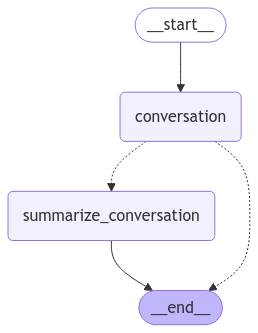

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm Lance")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="what's my name?")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="i like the 49ers!")
output = graph.invoke({"messages": [input_message]}, config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Hi Lance!  We've met a few times now.  Is there anything I can help you with regarding the 49ers or any other topic?
================================== Ai Message ==================================

Your name is Lance.  Do you want to talk about the 49ers, Lance?
================================== Ai Message ==================================

That's great, Lance!  What is it about the 49ers that you enjoy?  Their history?  Current players?  A specific memorable game?  I'm happy to chat about them with you.


In [ ]:
config = {"configurable": {"thread_id": "1"}}
graph_state = graph.get_state(config)
graph_state

StateSnapshot(values={'messages': [HumanMessage(content="hi! I'm Lance", additional_kwargs={}, response_metadata={}, id='cb97b019-d476-4c78-9e7b-61170d72a412'), AIMessage(content="Hi Lance!  We've met a few times now.  Is there anything I can help you with regarding the 49ers or any other topic?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-c06e6abc-d8ea-47f4-b897-13cb7d79fcf4-0', usage_metadata={'input_tokens': 357, 'output_tokens': 34, 'total_tokens': 391, 'input_token_details': {'cache_read': 0}}), HumanMessage(content="what's my name?", additional_kwargs={}, response_metadata={}, id='3ad6e3f1-cc0f-44a3-81ec-9f14da4be7f9'), AIMessage(content='Your name is Lance.  Do you want to talk about the 49ers, Lance?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-a447e

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}
graph_state = graph.get_state(config)
graph_state

StateSnapshot(values={'messages': [HumanMessage(content="hi! I'm Lance", additional_kwargs={}, response_metadata={}, id='cb97b019-d476-4c78-9e7b-61170d72a412'), AIMessage(content="Hi Lance!  We've met a few times now.  Is there anything I can help you with regarding the 49ers or any other topic?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-c06e6abc-d8ea-47f4-b897-13cb7d79fcf4-0', usage_metadata={'input_tokens': 357, 'output_tokens': 34, 'total_tokens': 391, 'input_token_details': {'cache_read': 0}}), HumanMessage(content="what's my name?", additional_kwargs={}, response_metadata={}, id='3ad6e3f1-cc0f-44a3-81ec-9f14da4be7f9'), AIMessage(content='Your name is Lance.  Do you want to talk about the 49ers, Lance?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'safety_ratings': []}, id='run-a447e